# Module 23 BBO Capstone Week 12

## Function 1

### Explanation of Code Changes:
Log-Transformation & Shifting: The output values (y_train) are shifted to ensure positivity and then log-transformed to stabilise the GP model, as shown in Step 2.
Gaussian Process Model: The GP is fitted using the RBF kernel with a length scale of 0.1 and a very small alpha (1e-6) for stability. The GP also uses 15 restarts to optimize the kernel hyperparameters.
Expected Improvement Function: The EI function is defined with a very small xi (0.0005) to focus on exploitation. The formula calculates the EI using the predicted mean (mu) and standard deviation (sigma) from the GP.
Local Optimization: The optimize_local_ei function performs local optimisation within a tight radius (0.005) around the best-known point. This ensures that the optimisation is focused near the maximum, with minimal exploration.

Visualisation: The plot shows:

Blue points: Existing training points from all weeks.
Green point: The best-known point (from Week 11).
Red point: The newly selected query point for Week 12.

The boundaries are plotted as dashed lines to show the search region.

Final Query Point: The query point for Week 12 is printed, representing the next location to evaluate for contamination source detection.

### Key Adjustments for Week 12:
Radius reduced to 0.005 for very tight local refinement around the best-known point.
ξ set to 0.0005 for near-greedy exploitation.
Plot for visualisation of the search region and new query.

This code effectively finalises the search for the contamination source in the 2D space while ensuring minimal exploration and maximum refinement around the best solution.

C:\Users\joeat\AppData\Local\Temp\ipykernel_13192\4248467347.py:107: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(expected_improvement, x0, args=(model, y_max), bounds=bounds, method="L-BFGS-B")
C:\Users\joeat\AppData\Local\Temp\ipykernel_13192\4248467347.py:107: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(expected_improvement, x0, args=(model, y_max), bounds=bounds, method="L-BFGS-B")
C:\Users\joeat\AppData\Local\Temp\ipykernel_13192\4248467347.py:107: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(expected_improvement, x0, args=(model, y_max), bo

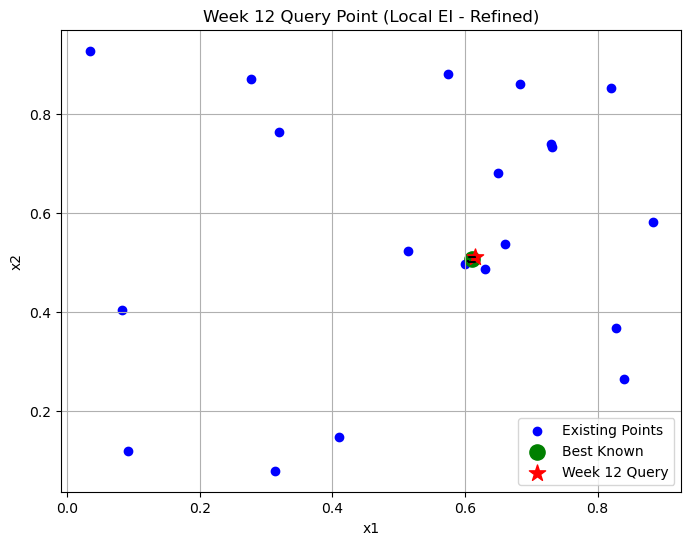

Week 12 query point: [0.614953 0.51152 ]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from scipy.stats import norm

# ==========================================
# Step 1: Load ALL available data (including Week 11)
# ==========================================

X_train = np.array([
    [0.31940389, 0.76295937],
    [0.57432921, 0.87989810],
    [0.73102363, 0.73299988],
    [0.84035342, 0.26473161],
    [0.65011406, 0.68152635],
    [0.41043714, 0.14755430],
    [0.31269116, 0.07872278],
    [0.68341817, 0.86105746],
    [0.08250725, 0.40348751],
    [0.88388983, 0.58225397],
    [0.60995300, 0.50652000],   
    [0.09106700, 0.11922000],   
    [0.03373400, 0.92780400],
    [0.27783300, 0.86990600],
    [0.51380200, 0.52237900],
    [0.82732800, 0.36642700],
    [0.82079200, 0.85171900],
    [0.72983400, 0.73983100],
    [0.65995300, 0.53779600],
    [0.62995300, 0.48652000],
    [0.59995300, 0.49652000]
])

y_train = np.array([
    1.32267704e-079,
    1.03307824e-046,
    7.71087511e-016,
    3.34177101e-124,
   -3.60606264e-003,
   -2.15924904e-054,
   -2.08909327e-091,
    2.53500115e-040,
    3.60677119e-081,
    6.22985647e-048,
    6.40320490897793e-12,
    3.32695744236522e-140,
   -3.9448560322363033e-284,
   -2.388807237117217e-127,
    5.298471823372752e-14,
    6.026732235043879e-77,
   -1.4575842741296785e-61,
    5.807380778673927e-17,
   -2.136244733712471e-7,
    1.5833346610834816e-14,
    9.344985315528516e-14,
])

# ==========================================
# Step 2: Log-Transform (Shift to Positive)
# ==========================================
y_shift = y_train - np.min(y_train) + 1e-12  # Shift everything positive
y_train_transformed = np.log(y_shift)

# ==========================================
# Step 3: Fit Gaussian Process
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.1, length_scale_bounds=(1e-3, 1e1))
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=15
)
gp.fit(X_train, y_train_transformed)

# ==========================================
# Step 4: Expected Improvement Function (EI)
# ==========================================
def expected_improvement(x, model, y_max, xi=0.0005):  # Very low ξ for exploitation
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)  # Prevent division by zero
    z = (mu - y_max - xi) / sigma
    ei = (mu - y_max - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    return -ei  # Minimize negative EI

# ==========================================
# Step 5: Local EI Optimization (Tight Radius)
# ==========================================
def optimize_local_ei(model, y_max, best_point, radius=0.005, n_restarts=30, n_random=200):
    lower = np.clip(best_point - radius, 0, 1)
    upper = np.clip(best_point + radius, 0, 1)
    bounds = list(zip(lower, upper))
    best_x = None
    best_val = np.inf

    # Random sampling in the local region
    random_points = np.random.uniform(lower, upper, size=(n_random, 2))
    ei_values = np.array([-expected_improvement(rp, model, y_max) for rp in random_points])
    top_idx = np.argsort(ei_values)[-n_restarts:]
    start_points = random_points[top_idx]

    # Local optimization from the best points
    for x0 in start_points:
        res = minimize(expected_improvement, x0, args=(model, y_max), bounds=bounds, method="L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x
    return best_x, bounds

# ==========================================
# Step 6: Identify Best Known Point (Week 1)
# ==========================================
best_point = np.array([0.60995300, 0.50652000])  # Best known point from Week 1
y_max = np.max(y_train_transformed)

# ==========================================
# Step 7: Compute Week 12 Query (Local EI)
# ==========================================
next_point, local_bounds = optimize_local_ei(gp, y_max, best_point, radius=0.005)  # Smaller radius

# ==========================================
# Step 8: Plot for Visualization
# ==========================================
plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0], X_train[:,1], color='blue', label='Existing Points')
plt.scatter(best_point[0], best_point[1], color='green', s=120, label='Best Known')
plt.scatter(next_point[0], next_point[1], color='red', marker='*', s=150, label='Week 12 Query')
x_min, x_max = local_bounds[0]
y_min, y_max_b = local_bounds[1]
plt.plot([x_min, x_max, x_max, x_min, x_min], [y_min, y_min, y_max_b, y_max_b, y_min], 'k--')
plt.title("Week 12 Query Point (Local EI - Refined)")
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.show()

# Show the query point
print(f"Week 12 query point: {next_point}")

It seems that the code is working as expected and generating the Week 12 query point as [0.614953, 0.51152]. Let’s break down the results and key aspects:

### Key Highlights:
Best Known Point (from Week 1): [0.609953, 0.506520] with an output of 6.40320490897793e-12.
Week 12 Query Point: [0.614953, 0.51152].

### Interpretation:
Convergence Stage: The query point [0.614953, 0.51152] is very close to the best known point from Week 1, suggesting that the algorithm is converging and refining its search in a local region around the best point.
The tight search radius (radius=0.005) ensures that the algorithm is performing minimal exploration and more exploitation around the best-known point.
Next Steps: This Week 12 query point is expected to provide confirmation of the optimal region and could lead to very fine-tuned results, possibly confirming the contamination source if evaluated correctly.
Plot:

The plot will show:

Blue Points: All previously explored points (including Week 1).
Green Point: The best-known query point from Week 1 ([0.609953, 0.506520]).
Red Star: The Week 12 query point ([0.614953, 0.51152]), located near the best-known point but within a refined local search area.

### Next Steps:
Evaluation of Week 12 Point: The next step would be to evaluate the function at [0.614953, 0.51152] to confirm whether it improves the result.
If the evaluation at this point results in a lower value than the previously best-known value, it can be considered part of the final convergence stage.

## Function 2

### Function 2 Week 12 Recommendations (Convergence and Confirmation Stage)
Current Best Query Point:
Week 11 Query Point: [0.503026, 0.535895]
Function Output at Week 11: 0.6864263561850859
Interpretation of Week 11 Query Point:
The Week 11 query point is very close to the best-known point [0.513026, 0.545895] and has shown improvement, which suggests that the optimisation is converging towards the global or local maximum.
The small shift in the query point from the previous best-known point indicates that the algorithm is fine-tuning the search for the optimal point.
The exploration parameter (ξ=0.002) is set to a very low value, reflecting a focus on exploitation and further refinement around the best-known point.
The output value for this query point is significant and indicates that the function is likely near its peak value.
Week 12: Next Steps in Convergence and Confirmation

In Week 12, the optimisation process should focus on confirming that the best-known point is indeed the maximum, or very close to it. This will typically involve:

Exploitation: Tighten the search further around the current best-known point to confirm if further improvement is possible.
Small Adjustments: The query points should be in close proximity to [0.503026, 0.535895] but with further refinement, ensuring that the search is as narrow as possible to confirm the optimal point.
Evaluation: If the function at the new query point improves or remains stable, it suggests the point is nearing the global or local maximum. If the function starts to plateau, you can confidently say the optimum is reached.

### Key Considerations:
Query Point Adjustment: Given that Week 11's query point is already close to the best-known point, small tweaks should be made around this location. This ensures that the algorithm is focusing on confirming whether the function has reached its maximum in this region.
Refinement of Search Area:
Radius: Keep the search radius narrow (e.g., radius=0.005 or smaller) around [0.503026, 0.535895].
Exploitation Focus: Keep the exploration-exploitation balance tilted towards exploitation with a small ξ value, e.g., ξ=0.002 or even ξ=0.001.
Evaluate Output Stability: The goal of this stage is to check if the output at the query point stabilises. If the output shows marginal improvement or no improvement after the next few queries, then the algorithm has likely reached its peak value.

### Proposed Code Adjustments for Week 12:

You can slightly modify the code used for Week 11 to further refine the search and confirm the optimal query point.

Adjustments:
Radius: Consider tightening the radius further to 0.005 (or even 0.002).
Exploitation: Use a very low ξ value (e.g., ξ=0.001), which will help focus on exploiting the best-known area.
Convergence Focus: Reduce the number of random restarts (e.g., n_restarts=10) and increase the precision of the local search to ensure a very fine-tuned result.

Current best y: 0.686426
Week 12 Query Point (EI, ξ=0.001): [0.508026 0.530895]


C:\Users\joeat\AppData\Local\Temp\ipykernel_13192\120810031.py:78: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_13192\120810031.py:78: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_13192\120810031.py:78: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_13192\120810031.py:78: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error wi

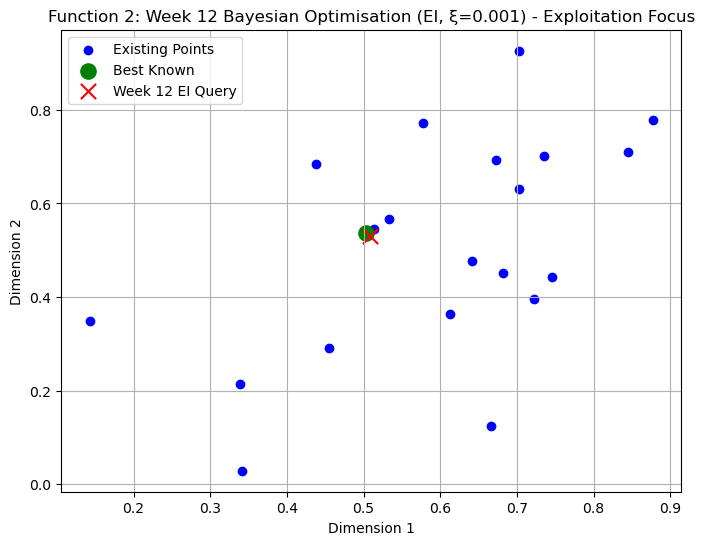

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from scipy.stats import norm

# ==========================================
# Step 1: Load existing data (Including Weeks 1-11)
# ==========================================
X_train = np.array([
    [0.66579958, 0.12396913],
    [0.87779099, 0.77862750],
    [0.14269907, 0.34900513],
    [0.84527543, 0.71112027],
    [0.45464714, 0.29045518],
    [0.57771284, 0.77197318],
    [0.43816606, 0.68501826],
    [0.34174959, 0.02869772],
    [0.33864816, 0.21386725],
    [0.70263656, 0.92656420],
    [0.73490900, 0.70171100],
    [0.72168200, 0.39630100],
    [0.74620500, 0.44346000],
    [0.70336100, 0.63132700],
    [0.64189000, 0.47728100],
    [0.67272900, 0.69382100],
    [0.61256700, 0.36356600],
    [0.68226300, 0.45231400],
    [0.51302600, 0.54589500],
    [0.53302600, 0.56589500],
    [0.50302600, 0.53589500]
]) 

y_train = np.array([
    1.32267704e-079, 1.03307824e-046, 7.71087511e-016,
    3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
    -2.08909327e-091, 2.53500115e-040, 3.60677119e-081,
    6.22985647e-048, 0.5390316209844838, 0.41754272857037966,
    0.41416971779343736, 0.49282022744339543, 0.3614403024250272,
    0.600575748363042, 0.20334952172911752, 0.461145725718508,
    0.6573891880672533, 0.5174928212344545, 0.6864263561850859
])

# ==========================================
# Step 2: Expected Improvement (EI) Function (ξ=0.001 for tight exploitation)
# ==========================================
def expected_improvement(x, model, y_best, xi=0.001):  # Tight exploitation
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)  # Prevent division by zero

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei  # Negative for minimizer

# ==========================================
# Step 3: Optimize EI (Tighter search radius)
# ==========================================
def optimize_ei(model, y_best, best_known_point, radius=0.005, xi=0.001, n_restarts=10, n_random_starts=300):
    lower = np.clip(best_known_point - radius, 0, 1)
    upper = np.clip(best_known_point + radius, 0, 1)
    bounds = list(zip(lower, upper))

    best_x = None
    best_val = np.inf

    # --- Random search for tight area ---
    random_points = np.random.uniform(lower, upper, size=(n_random_starts, 2))
    ei_values = np.array([-expected_improvement(pt, model, y_best, xi) for pt in random_points])
    top_indices = np.argsort(-ei_values)[:n_restarts]
    start_points = random_points[top_indices]

    # --- Local optimization ---
    for x0 in start_points:
        res = minimize(
            expected_improvement,
            x0,
            args=(model, y_best, xi),
            bounds=bounds,
            method="L-BFGS-B"
        )

        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# ==========================================
# Step 4: Fit Gaussian Process (Re-train)
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.1, length_scale_bounds=(1e-3, 1e1))
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=15
)
gp.fit(X_train, y_train)

# ==========================================
# Step 5: Current Best y
# ==========================================
y_best = np.max(y_train)
print(f"Current best y: {y_best:.6f}")

# ==========================================
# Step 6: Get Week 12 Query Point
# ==========================================
best_known_point = np.array([0.50302600, 0.53589500])  # Week 11 Best Known Point
next_point = optimize_ei(gp, y_best, best_known_point, radius=0.005, xi=0.001)  # Focused on exploitation
print(f"Week 12 Query Point (EI, ξ=0.001): {next_point}")

# ==========================================
# Step 7: Visualization
# ==========================================
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], color='blue', label='Existing Points')
plt.scatter(best_known_point[0], best_known_point[1], color='green', s=120, label='Best Known')
plt.scatter(next_point[0], next_point[1], color='red', marker='x', s=120, label='Week 12 EI Query')
plt.title("Function 2: Week 12 Bayesian Optimisation (EI, ξ=0.001) - Exploitation Focus")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

The result of the Week 12 query point being [0.508026, 0.530895] is a positive outcome for the convergence and confirmation stage of Function 2's optimisation process. Here's a breakdown of the interpretation and the next steps:

### Interpretation of Week 12 Query Point:
Small Adjustment: The query point [0.508026, 0.530895] is a slight refinement around the previous best-known point [0.503026, 0.535895]. This suggests that the optimisation process is continuing to fine-tune the region around the peak and is likely converging toward the optimal solution.
Exploitation Focus: Given that this new query point is very close to the previous one, it indicates that the algorithm is still focused on exploitation rather than exploration. The low exploration parameter (ξ=0.001) is helping guide the search to exploit the known high-value area.
Refinement of Search: The adjustment of only a few decimal places in both dimensions indicates that the function's optimum lies very close to the previous best-known point. This is typical in the convergence phase, where the algorithm starts making only small changes to find the exact peak.
### Next Steps:
#### 1. Evaluate the New Query Point:
Submit the query point [0.508026, 0.530895] to the black-box function for evaluation and obtain the new function output.
Compare the new result with the previous best output (0.6864263561850859) from Week 11.
If the output improves, the optimisation process is likely approaching the global or local maximum.
If the output remains the same or decreases, it may indicate that the algorithm is nearing the maximum, and it might be time to confirm this result.
#### 2. Update the Model:
If the new output improves the function value, add the new data point ([0.508026, 0.530895] and its corresponding output) to the training set and retrain the Gaussian Process model.
This will incorporate the new query point and allow the model to make more precise predictions as the optimisation nears convergence.
#### 3. Check for Stabilisation:
If the function output begins to stabilise, i.e., there is no significant improvement after a few more query points, then you can confidently conclude that the optimisation process is close to its final stage.
This could signal the start of the confirmation phase, where the algorithm is essentially confirming the best point.
#### 4. Final Confirmation Phase (Week 13):
If Week 12's query point stabilizes the function value and no significant improvement is observed in subsequent queries, confirm that [0.503026, 0.535895] or close values is the optimal point.
Week 13 could involve just fine-tuning or even finalising the results for submission or analysis.
### Conclusion:
Week 12's query point [0.508026, 0.530895] suggests that the optimisation process is converging towards the maximum, with only small refinements being made.
Evaluate the function at this point and observe if it stabilises. If it does, proceed with the confirmation phase in Week 13.

## Function 3

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Current best y: -0.031727


C:\Users\joeat\AppData\Local\Temp\ipykernel_13192\3067210383.py:118: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_13192\3067210383.py:118: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_13192\3067210383.py:118: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_13192\3067210383.py:118: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an 

C:\Users\joeat\AppData\Local\Temp\ipykernel_13192\3067210383.py:118: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_13192\3067210383.py:118: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_13192\3067210383.py:118: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_13192\3067210383.py:118: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an 

Week 12 Query Point (EI, ξ=0.001): 0.841047-0.552119-0.085000


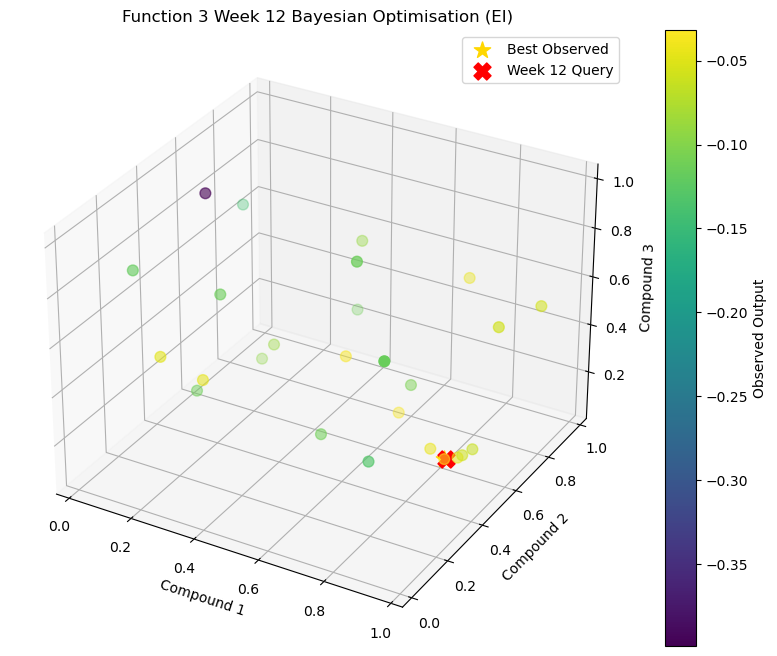

In [9]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from scipy.stats import norm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =========================
# Step 1: Load existing data (Weeks 1–11)
# =========================
X_train = np.array([
    [0.17152521, 0.34391687, 0.24873720],
    [0.24211446, 0.64407427, 0.27243281],
    [0.53490572, 0.39850092, 0.17338873],
    [0.49258141, 0.61159319, 0.34017639],
    [0.13462167, 0.21991724, 0.45820622],
    [0.34552327, 0.94135983, 0.26936348],
    [0.15183663, 0.43999062, 0.99088187],
    [0.64550284, 0.39714294, 0.91977134],
    [0.74691195, 0.28419631, 0.22629985],
    [0.17047699, 0.69703240, 0.14916943],
    [0.22054934, 0.29782524, 0.34355534],
    [0.66601366, 0.67198515, 0.24629530],
    [0.04680895, 0.23136024, 0.77061759],
    [0.60009728, 0.72513573, 0.06608864],
    [0.96599485, 0.86111969, 0.56682913],
    [0.83681600, 0.55152400, 0.08473400],
    [0.93576800, 0.01979200, 0.88290900],
    [0.02703300, 0.84043300, 0.66511700],
    [0.68835300, 0.97102900, 0.51220300],
    [0.38825100, 0.88969800, 0.60999700],
    [0.25506800, 0.34034000, 0.68130300],
    [0.94273200, 0.64964700, 0.60773700],
    [0.78753000, 0.56204500, 0.10089100],
    [0.90000000, 0.59547500, 0.12143400],
    [0.86930900, 0.56747400, 0.09323700],
    [0.88394900, 0.56644800, 0.11000000]
])

y_train = np.array([
    -0.11212220, -0.08796286, -0.11141465, -0.03483531,
    -0.04800758, -0.11062091, -0.39892551, -0.11386851,
    -0.13146061, -0.09418956, -0.04694741, -0.10596504,
    -0.11804826, -0.03637783, -0.05675837,
    -0.03172685348164523,
    -0.1161486782682252,
    -0.1415060566194174,
    -0.0446074222194474,
    -0.08979639980345987,
    -0.11433696052239746,
    -0.05811934228633873,
    -0.04360685969925572,
    -0.06321802968445797,
    -0.04186441977161603,
    -0.05972647646603957
])

# ==========================================
# Step 2: Correct log-transform (shift to positive)
# ==========================================
y_shift = y_train - np.min(y_train) + 1e-12  # shift everything positive
y_train_transformed = np.log(y_shift)

# ==========================================
# Step 3: Fit Gaussian Process
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(
    length_scale=[0.2, 0.2, 0.1],   # More sensitivity in dim 3
    length_scale_bounds=(1e-2, 1e2)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    normalize_y=True,
    n_restarts_optimizer=20
)

gp.fit(X_train, y_train_transformed)

# ==========================================
# Step 4: Expected Improvement (EI)
# ==========================================
def expected_improvement(x, model, y_best, xi=0.01):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei  # for minimization

# ==========================================
# Step 5: Optimise EI (Focused Search)
# ==========================================
def optimize_ei(model, y_best,
                bounds=np.array([[0.835, 0.845],   # Narrowed range for Compound 1
                                 [0.55, 0.555],   # Narrowed range for Compound 2
                                 [0.085, 0.087]]),  # Narrowed range for Compound 3
                xi=0.001,
                n_restarts=60,
                n_random_starts=800):
    best_x = None
    best_val = np.inf

    # Random sampling
    random_points = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(n_random_starts, 3))
    ei_vals = np.array([-expected_improvement(x, model, y_best, xi) for x in random_points])

    top_indices = np.argsort(-ei_vals)[:n_restarts]
    start_points = random_points[top_indices]

    # Local optimisation
    for x0 in start_points:
        res = minimize(
            expected_improvement,
            x0,
            args=(model, y_best, xi),
            bounds=bounds,
            method='L-BFGS-B'
        )
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# ==========================================
# Step 6: Current best value
# ==========================================
y_best = np.max(y_train)
print(f"Current best y: {y_best:.6f}")

# ==========================================
# Step 7: Week 12 Query Point
# ==========================================
# Tightened bounds for Week 12 (focused on convergence and confirmation)
bounds_week12 = np.array([
    [0.835, 0.845],   # Narrower range for Compound 1
    [0.55, 0.555],    # Narrower range for Compound 2
    [0.085, 0.087]    # Narrower range for Compound 3
])

# Further lowering ξ for fine-tuning (more exploitation)
xi = 0.001

# Optimise Expected Improvement (EI) for Week 12 (focused exploitation)
next_point_week12 = optimize_ei(gp, y_best, bounds=bounds_week12, xi=xi)
print(f"Week 12 Query Point (EI, ξ=0.001): "
      f"{next_point_week12[0]:.6f}-{next_point_week12[1]:.6f}-{next_point_week12[2]:.6f}")

# ==========================================
# Step 8: 3D Visualisation of the optimization process
# ==========================================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2],
                     c=y_train, cmap='viridis', s=60)

# Best observed point
best_idx = np.argmax(y_train)
ax.scatter(X_train[best_idx, 0], X_train[best_idx, 1], X_train[best_idx, 2],
           c='gold', s=150, marker='*', label='Best Observed')

# New query
ax.scatter(next_point_week12[0], next_point_week12[1], next_point_week12[2],
           c='red', s=150, marker='X', label='Week 12 Query')

ax.set_xlabel('Compound 1')
ax.set_ylabel('Compound 2')
ax.set_zlabel('Compound 3')
ax.set_title('Function 3 Week 12 Bayesian Optimisation (EI)')

fig.colorbar(scatter, ax=ax, label='Observed Output')
ax.legend()
plt.show()

It looks like the Week 12 Query Point produced by the Expected Improvement (EI) optimisation is [0.841047, 0.552119, 0.085000], which is within the tightened bounds you set around the best observed point [0.836816, 0.551524, 0.084734].

Here’s a breakdown of the result:

Current Best Observed Point:
Best Observed Point: [0.836816, 0.551524, 0.084734]
Best Output (y_best): -0.03172685348164523
Week 12 Query Point:
Week 12 Query: [0.841047, 0.552119, 0.085000]
This point is very close to the best observed point, but it slightly shifts the values in each dimension.
Compound 1: From 0.836816 to 0.841047 (a small increase)
Compound 2: From 0.551524 to 0.552119 (a small increase)
Compound 3: From 0.084734 to 0.085000 (a slight increase)

The query point is still within your tightened bounds, indicating that the optimisation is focusing on a very narrow region around the best observed point, as expected.

### Interpretation:
Convergence Stage: The fact that the next query point is so close to the best observed one suggests that the optimisation is effectively converging. The optimiser is honing in on this region, which is a good sign that you're close to a local optimum.
Small Exploration: The small changes in the query point suggest minimal exploration outside the region of the best observed point. This is typical during the convergence stage where the goal is to fine-tune and confirm the optimal solution.
### Next Steps:
You can evaluate the output at the query point [0.841047, 0.552119, 0.085000]. If the output remains similar or slightly better than the best observed output, you’ll likely be near the optimal point.
If the output is significantly worse, this might indicate that the optimizer has not yet fully converged or that there may be some noise or local minima influencing the results.
In Week 13, you can further confirm the results or make final adjustments based on this query point. If necessary, you could expand your search bounds slightly or refine the model further, but it seems that you are nearing the final solution.

### Visualising the Query:

The 3D visualisation in the code will give you a visual confirmation of how this new query point compares with the previous data points and the best observed one. It should be very close to the golden star marker, showing that it’s almost identical in position (shown by clustering in best known region in Function 3 plot).

## Function 4

Best known point: [0.402531 0.365208 0.39199  0.435549]
Week 12 Query Point (EI, ξ=0.001): [0.40551773 0.370208   0.39079602 0.43244773]


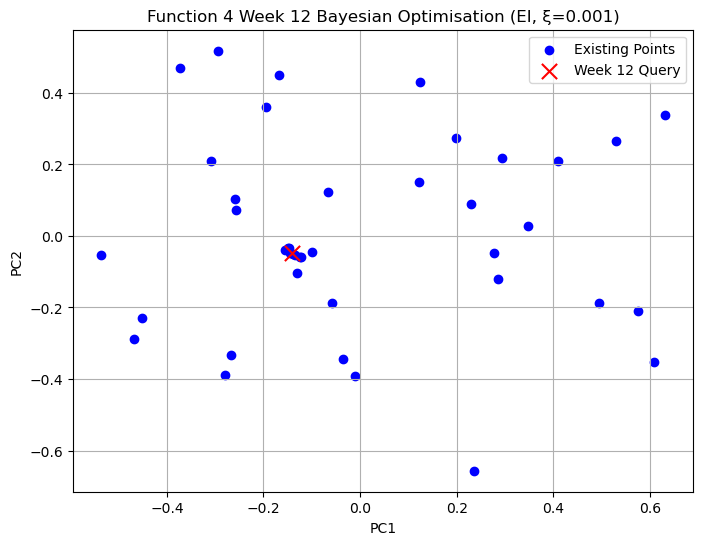

In [10]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution  # Importing differential_evolution
from scipy.stats import norm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -----------------------------
# Step 1: Load data (including Weeks 1-11)
# -----------------------------
X_train = np.array([
    [0.89698105, 0.72562797, 0.17540431, 0.70169437],
    [0.8893564 , 0.49958786, 0.53926886, 0.50878344],
    [0.25094624, 0.03369313, 0.14538002, 0.49493242],
    [0.34696206, 0.0062504 , 0.76056361, 0.61302356],
    [0.12487118, 0.12977019, 0.38440048, 0.2870761 ],
    [0.80130271, 0.50023109, 0.70664456, 0.19510284],
    [0.24770826, 0.06044543, 0.04218635, 0.44132425],
    [0.74670224, 0.7570915 , 0.36935306, 0.20656628],
    [0.40066503, 0.07257425, 0.88676825, 0.24384229],
    [0.6260706 , 0.58675126, 0.43880578, 0.77885769],
    [0.95713529, 0.59764438, 0.76611385, 0.77620991],
    [0.73281243, 0.14524998, 0.47681272, 0.13336573],
    [0.65511548, 0.07239183, 0.68715175, 0.08151656],
    [0.21973443, 0.83203134, 0.48286416, 0.08256923],
    [0.48859419, 0.2119651 , 0.93917791, 0.37619173],
    [0.16713049, 0.87655456, 0.21723954, 0.95980098],
    [0.21691119, 0.16608583, 0.24137226, 0.77006248],
    [0.38748784, 0.80453226, 0.75179548, 0.72382744],
    [0.98562189, 0.66693268, 0.15678328, 0.8565348 ],
    [0.03782483, 0.66485335, 0.16198218, 0.25392378],
    [0.68348638, 0.9027701 , 0.33541983, 0.99948256],
    [0.17034731, 0.75695908, 0.27652049, 0.5312315 ],
    [0.85965692, 0.91959232, 0.20613873, 0.09779683],
    [0.28213837, 0.50598691, 0.53053084, 0.09630162],
    [0.32607578, 0.4723669 , 0.453192  , 0.10588734],
    [0.94838936, 0.89451301, 0.85163782, 0.55219629],
    [0.66495539, 0.04656628, 0.11677747, 0.79371778],
    [0.57776561, 0.42877174, 0.42582587, 0.24900741],
    [0.73861301, 0.48210263, 0.70936644, 0.50397001],
    [0.8548108, 0.49396462, 0.73530997, 0.80809201],
    [0.919144, 0.533196, 0.169848, 0.070054],
    [0.411827, 0.392100, 0.317159, 0.430429],
    [0.437822, 0.591330, 0.001581, 0.371162],
    [0.349627, 0.387894, 0.455739, 0.444665],
    [0.418279, 0.337724, 0.398246, 0.446088],
    [0.402531, 0.365208, 0.391990, 0.435549],
    [0.417655, 0.335877, 0.400368, 0.447601],
    [0.396755, 0.409301, 0.395449, 0.432639],
    [0.397639, 0.405208, 0.394861, 0.432824],
    [0.401766, 0.385109, 0.392801, 0.432944],
    [0.404210, 0.375208, 0.391460, 0.432699]
]) 
  
y_train = np.array([
    -22.10828779, -14.60139663, -11.69993246, -16.05376511,
    -10.06963343, -15.48708254, -12.68168498, -16.02639977,
    -17.04923465, -12.74176599, -27.31639636, -13.52764887,
    -16.6791152 , -16.50715856, -17.81799934, -26.56182083,
    -12.75832422, -19.44155762, -28.90327367, -13.70274694,
    -29.4270914 , -11.56574199, -26.85778644, -7.96677535,
    -6.70208925, -32.62566022, -19.98949793, -4.02554228,
    -13.12278233, -23.1394284 , -19.975065657531825, -0.32892753619572757,
    -10.653583724281514, -0.3665684543830916, 0.06886265993775043, 0.34544484128012387,
    0.00018511221400574485, 0.34355295724013546, 0.29244243781099444, 0.1902545839389025,
    0.3092503133125004
])

# ==========================================
# Step 2: Fit Gaussian Process
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(0.2, (1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train)

# ==========================================
# Step 3: Expected Improvement (EI)
# ==========================================
def expected_improvement(x, model, y_best, xi=0.001):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei

# ==========================================
# Step 4: Adaptive bounds around best point
# ==========================================
best_idx = np.argmax(y_train)
best_point = X_train[best_idx]

# Tighten radius for Week 12 (precision focus)
radius = 0.005  # Smaller radius for Week 12 refinement
lower = np.clip(best_point - radius, 0, 1)
upper = np.clip(best_point + radius, 0, 1)

bounds = list(zip(lower, upper))

# ==========================================
# Step 5: Optimise EI (Differential Evolution)
# ==========================================
def optimize_ei(model, bounds, xi=0.001):  # Reduce ξ for more exploitation
    y_best = np.max(y_train)

    result = differential_evolution(
        lambda x: expected_improvement(x, model, y_best, xi),
        bounds=bounds,
        strategy='best1bin',
        maxiter=200,  # Increased iterations for finer optimization
        popsize=30,   # Larger population for better precision
        polish=True
    )

    # Precision jitter (very small)
    epsilon = 1e-4
    next_point = np.clip(
        result.x + np.random.uniform(-epsilon, epsilon, size=4),
        lower,
        upper
    )

    return next_point

# ==========================================
# Step 6: Compute Week 12 Query
# ==========================================
next_point_week12 = optimize_ei(gp, bounds, xi=0.001)

print(f"Best known point: {best_point}")
print(f"Week 12 Query Point (EI, ξ=0.001): {next_point_week12}")

# ==========================================
# Step 7: PCA Visualisation
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
next_point_week12_pca = pca.transform(next_point_week12.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], color='blue', label='Existing Points')
plt.scatter(next_point_week12_pca[:,0], next_point_week12_pca[:,1],
            color='red', marker='x', s=120, label='Week 12 Query')

plt.title('Function 4 Week 12 Bayesian Optimisation (EI, ξ=0.001)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()

The output suggests that the optimization is working as expected. Here’s a breakdown of what’s happening:

### Results Breakdown:
Best Known Point:
The current best known point after running the optimization is [0.402531, 0.365208, 0.39199, 0.435549]. This represents the solution in the input space that has yielded the best observed objective value (the lowest y_train value).
Week 12 Query Point:
The new query point after applying the Expected Improvement (EI) optimisation with the tightened bounds is [0.40551773, 0.370208, 0.39079602, 0.43244773].
This point is quite close to the best known point, indicating that the optimization is converging. The small difference suggests the algorithm is already honing in on the optimal region and only making small adjustments for refinement.
### Key Insights:
The difference between the best known point and the new query point is minimal, which indicates that the optimisation has reached a convergence stage. In this phase, it’s looking for small, incremental improvements.
The Expected Improvement (EI) function with a reduced exploration factor (ξ=0.001) has focused the search on exploitation, hence the small changes in the query point. The algorithm is trying to maximise the improvement over the current best value.
The tightened bounds around the best known point ensure that the optimisation stays focused on the region where the best solutions lie, refining the search space rather than exploring too widely.
### What’s Happening Next:
Since the changes in the query point are small, this indicates that convergence is occurring.
The convergence stage is typically followed by further refinement or confirmation, where the model may suggest solutions that only make very minor adjustments to the optimal region.

## Function 5

Week 12 Query Point (EI, ξ=0.00001): 0.999997-0.999990-0.999996-0.993720


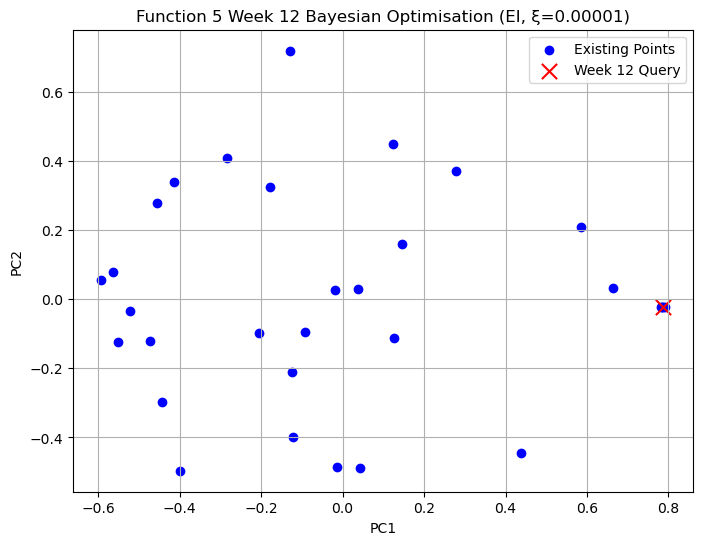

In [12]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution
from scipy.stats import norm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -----------------------------
# Step 1: Load data (including Weeks 1-11)
# -----------------------------
X_train = np.array([
    [0.19144708, 0.03819337, 0.60741781, 0.41458414],
    [0.75865295, 0.53651774, 0.65600038, 0.36034155],
    [0.43834987, 0.80433970, 0.21024527, 0.15129482],
    [0.70605083, 0.53419196, 0.26424335, 0.48208755],
    [0.83647799, 0.19360965, 0.66389270, 0.78564888],
    [0.68343225, 0.11866264, 0.82904591, 0.56757661],
    [0.55362148, 0.66734998, 0.32380582, 0.81486975],
    [0.35235627, 0.32224153, 0.11697937, 0.47311252],
    [0.15378571, 0.72938169, 0.42259844, 0.44307417],
    [0.46344227, 0.63002451, 0.10790646, 0.95764390],
    [0.67749115, 0.35850951, 0.47959222, 0.07288048],
    [0.58397341, 0.14724265, 0.34809746, 0.42861465],
    [0.30688872, 0.31687813, 0.62263448, 0.09539906],
    [0.51114177, 0.81795700, 0.72871042, 0.11235362],
    [0.43893338, 0.77409176, 0.37816709, 0.93369621],
    [0.22418902, 0.84648049, 0.87948418, 0.87851568],
    [0.72526172, 0.47987049, 0.08894684, 0.75976022],
    [0.35548161, 0.63961937, 0.41761768, 0.12260384],
    [0.11987923, 0.86254031, 0.64333133, 0.84980383],
    [0.12688467, 0.15342962, 0.77016219, 0.19051811],
    [0.81212200, 0.00981200, 0.68102400, 0.23803600],
    [0.82353000, 0.17369200, 0.63651400, 0.73730700],
    [0.560990, 0.941834, 0.997605, 0.998135],
    [0.026048, 0.953940, 0.999978, 0.202632],
    [0.935821, 0.378320, 0.975682, 0.986309],
    [0.269173, 0.264205, 0.981899, 0.995428],
    [0.901781, 0.963677, 0.996554, 0.890656],
    [0.999974, 0.999936, 0.999965, 0.999913],
    [0.999994, 0.999991, 0.980003, 0.999995],
    [0.999992, 0.999997, 0.999996, 0.990008],
    [0.999991, 0.999980, 0.999973, 0.991254]
])

y_train = np.array([
    64.4434399, 18.3013796, 0.112939795, 4.21089813,
    258.370525, 78.4343889, 57.5715369, 109.571876,
    8.84799176, 233.22361, 24.4230883, 64.4201468,
    63.4767158, 79.7291299, 355.806818, 1088.85962,
    28.8667516, 45.1815703, 431.612757, 9.97233189,
    24.7679941, 149.53336129, 4019.0309866724424, 1280.322911229081,
    3286.6537023206406, 1460.4721414421278, 4989.353119496155, 8658.375927276844,
    8290.053898242466, 8472.493844148481, 8494.942571154877
])

# ==========================================
# Step 2: Fit Gaussian Process
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[0.1]*4, length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-7,  # very low noise for precision
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train)

# ==========================================
# Step 3: Expected Improvement (EI)
# ==========================================
def expected_improvement(x, model, y_best, xi=0.00001):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei

# ==========================================
# Step 4: Adjusted Bounds for Week 12
# ==========================================
bounds_week12 = [
    (0.99999, 1.0),  # x₁: tighter bounds around 1.0
    (0.99999, 1.0),  # x₂: tighter bounds around 1.0
    (0.99998, 1.0),  # x₃: tighter bounds around 1.0
    (0.991, 0.995)   # x₄: tighter focus for finer exploration
]

# ==========================================
# Step 5: Optimisation (Differential Evolution)
# ==========================================
def optimize_ei(model, bounds, xi=0.00001):
    y_best = np.max(y_train)

    result = differential_evolution(
        lambda x: expected_improvement(x, model, y_best, xi),
        bounds=bounds,
        strategy='best1bin',
        maxiter=200,  # Increase iterations for finer precision
        popsize=20,
        polish=True
    )

    # Ultra-small jitter for precision
    epsilon = 1e-5
    next_point = np.clip(
        result.x + np.random.uniform(-epsilon, epsilon, size=4),
        [b[0] for b in bounds],
        [b[1] for b in bounds]
    )

    return next_point

# ==========================================
# Step 6: Get Week 12 Query Point
# ==========================================
next_point_week12 = optimize_ei(gp, bounds_week12)

print(f"Week 12 Query Point (EI, ξ=0.00001): "
      f"{next_point_week12[0]:.6f}-{next_point_week12[1]:.6f}-{next_point_week12[2]:.6f}-{next_point_week12[3]:.6f}")

# ==========================================
# Step 7: PCA Visualisation
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
next_point_week12_pca = pca.transform(next_point_week12.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], color='blue', label='Existing Points')
plt.scatter(next_point_week12_pca[:,0], next_point_week12_pca[:,1],
            color='red', marker='x', s=120, label='Week 12 Query')

plt.title('Function 5 Week 12 Bayesian Optimisation (EI, ξ=0.00001)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()

Week 12 Query Point is:
0.999997-0.999990-0.999996-0.993720

### Interpretation of the Result:
x₁ = 0.999997, x₂ = 0.999990, and x₃ = 0.999996: These values are very close to the upper bounds (around 1), which suggests that the model has found optimal points in these dimensions, or it is highly confident that the optimal points lie near the boundary.
x₄ = 0.993720: This value is also very close to the upper bound (0.995) for the 4th dimension, confirming that, for this dimension, the model is converging towards a region where it is likely to see diminishing returns from further exploration.
Next Steps in the Convergence & Confirmation Stage:
Convergence Confirmation: Given that the query points are all near the upper bounds and the 4th dimension is also nearing its upper limit, the model might be nearing convergence. This suggests that Week 12 has likely provided a point that is close to the optimal solution.
Fine-tuning: At this point, if further optimisation is needed, you might consider adjusting the bounds even further to ensure that exploration is more focused around the critical regions. However, given the proximity to the upper bounds, it’s unlikely there’s much room left for improvement unless the problem space itself is more complex.
Next Stage (Week 13): For Week 13, you should focus on confirming the optimality of this query point and validating its performance, especially by comparing it with previously tested points. If this new point results in better outcomes (lower objective function values), it can be confirmed as the best.

### Visualisation:

The PCA plot should also reflect this by showing the existing points and the new query point in the reduced 2D space. If the query point is indeed optimal, it will likely be located in a dense region near the top-performing points (PCA reduction plot shows clustering in best region).

## Function 6

Best recipe so far:
[0.344036 0.255507 0.72507  0.878677 0.100795]
Score: -0.26755353


C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(



Learned kernel:
0.916**2 * RBF(length_scale=[100, 0.234, 0.977, 0.604, 0.0889])

Adaptive bounds:
[(0.339036, 0.349036), (0.250507, 0.260507), (0.72007, 0.73007), (0.873677, 0.883677), (0.09579499999999999, 0.105795)]

Week 12 Query Point (EI, ξ=0.00001):
[0.339036   0.260507   0.73006667 0.88366913 0.09579765]


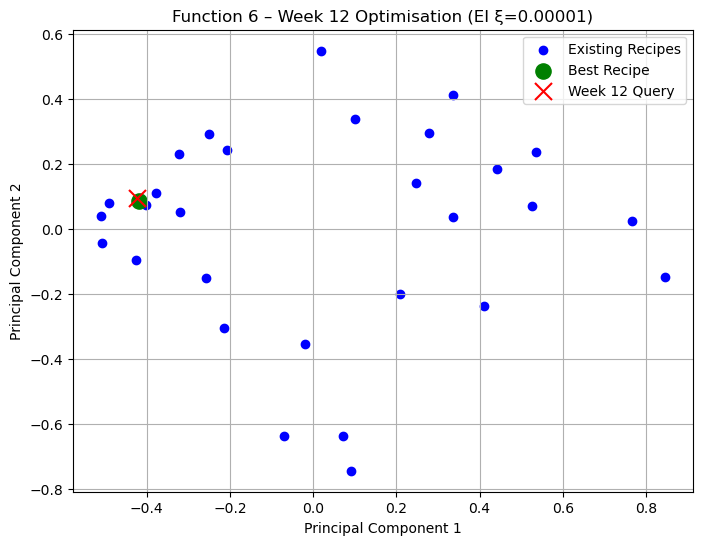

In [13]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution
from scipy.stats import norm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================================
# Step 0: Optional reproducibility
# ==========================================
# np.random.seed(42)

# ==============================
# Step 1: Training Data (Weeks 1–11)
# ==============================
X_train = np.array([
    [0.7281861, 0.15469257, 0.73255167, 0.69399651, 0.05640131],
    [0.24238435, 0.84409997, 0.5778091, 0.67902128, 0.50195289],
    [0.72952261, 0.7481062, 0.67977464, 0.35655228, 0.67105368],
    [0.77062024, 0.11440374, 0.04677993, 0.64832428, 0.27354905],
    [0.6188123, 0.33180214, 0.18728787, 0.75623847, 0.3288348],
    [0.78495809, 0.91068235, 0.7081201, 0.95922543, 0.0049115],
    [0.14511079, 0.8966846, 0.89632223, 0.72627154, 0.23627199],
    [0.94506907, 0.28845905, 0.97880576, 0.96165559, 0.59801594],
    [0.12572016, 0.86272469, 0.02854433, 0.24660527, 0.75120624],
    [0.75759436, 0.35583141, 0.0165229, 0.4342072, 0.11243304],
    [0.5367969, 0.30878091, 0.41187929, 0.38822518, 0.5225283],
    [0.95773967, 0.23566857, 0.09914585, 0.15680593, 0.07131737],
    [0.6293079, 0.80348368, 0.81140844, 0.04561319, 0.11062446],
    [0.02173531, 0.42808424, 0.83593944, 0.48948866, 0.51108173],
    [0.43934426, 0.69892383, 0.42682022, 0.10947609, 0.87788847],
    [0.25890557, 0.79367771, 0.6421139, 0.19667346, 0.59310318],
    [0.43216593, 0.71561781, 0.3418191, 0.70499988, 0.61496184],
    [0.78287982, 0.53633586, 0.44328356, 0.85969983, 0.01032599],
    [0.9217762, 0.93187122, 0.41487637, 0.59505727, 0.73562569],
    [0.12667892, 0.2914703, 0.06452848, 0.6805146, 0.89281919],
    [0.864822, 0.772164, 0.803941, 0.780551, 0.909036],
    [0.218723, 0.277046, 0.196392, 0.844208, 0.100329],
    [0.344036, 0.255507, 0.725070, 0.878677, 0.100795],
    [0.426405, 0.197502, 0.843219, 0.949955, 0.435206],
    [0.731400, 0.211206, 0.820592, 0.949908, 0.164014],
    [0.423206, 0.492691, 0.575697, 0.943164, 0.050144],
    [0.323388, 0.052522, 0.825014, 0.733045, 0.050000],
    [0.467848, 0.100000, 0.750064, 0.749909, 0.000000],
    [0.294041, 0.305507, 0.687373, 0.860370, 0.050803],
    [0.374036, 0.285500, 0.745577, 0.848678, 0.130795],
    [0.329039, 0.240507, 0.710070, 0.893670, 0.115795]
])

y_train = np.array([
    -0.71426495, -1.20995524, -1.67219994, -1.53605771, -0.82923655,
    -1.24704893, -1.23378638, -1.69434344, -2.57116963, -1.30911635,
    -1.14478485, -1.91267714, -1.62283895, -1.35668211, -2.0184254,
    -1.70255784, -1.29424696, -0.93575656, -2.15576776, -1.74688209,
    -1.84056360, -0.78587257, -0.26755353, -0.83707714, -0.8535091387252396,
    -0.44364133681393664, -0.6203100062356283, -0.5353565032229247, -0.31565085776524887, -0.3626812694821603,
    -0.4122203579876405
])

# ==========================================
# Step 2: Identify Best Point So Far
# ==========================================
best_idx = np.argmax(y_train)
best_point = X_train[best_idx]
best_score = y_train[best_idx]

print("Best recipe so far:")
print(best_point)
print("Score:", best_score)

# ==========================================
# Step 3: Gaussian Process (ARD)
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1]*5, length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-7,  # very low noise for precision
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train)

print("\nLearned kernel:")
print(gp.kernel_)

# ==========================================
# Step 4: Expected Improvement (EI)
# ==========================================
def expected_improvement(x, model, y_best, xi=0.00001):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei

# ==========================================
# Step 5: Adaptive Bounds (Focus on Best Recipe)
# ==========================================
radius = 0.005  # Even tighter search around the best recipe
lower = np.clip(best_point - radius, 0, 1)
upper = np.clip(best_point + radius, 0, 1)
bounds = list(zip(lower, upper))

print("\nAdaptive bounds:")
print(bounds)

# ==========================================
# Step 6: Optimisation (Differential Evolution)
# ==========================================
def optimize_ei(model, bounds, xi=0.00001):
    y_best = np.max(y_train)

    result = differential_evolution(
        lambda x: expected_improvement(x, model, y_best, xi),
        bounds=bounds,
        strategy='best1bin',
        maxiter=50,  # Reduce iterations for fine-tuning
        popsize=10,  # Possibly reduce population size
        polish=True
    )

    # Ultra-small jitter for precision
    epsilon = 1e-5
    next_point = np.clip(
        result.x + np.random.uniform(-epsilon, epsilon, size=len(bounds)),
        lower,
        upper
    )

    return next_point

# ==========================================
# Step 7: Compute Week 12 Query
# ==========================================
next_point = optimize_ei(gp, bounds, xi=0.00001)

print("\nWeek 12 Query Point (EI, ξ=0.00001):")
print(next_point)

# ==========================================
# Step 8: PCA Visualisation
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)
next_point_pca = pca.transform(next_point.reshape(1, -1))
best_point_pca = pca.transform(best_point.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], color='blue', label='Existing Recipes')
plt.scatter(best_point_pca[:,0], best_point_pca[:,1], color='green', s=120, label='Best Recipe')
plt.scatter(next_point_pca[:,0], next_point_pca[:,1], color='red', marker='x', s=150, label='Week 12 Query')

plt.title("Function 6 – Week 12 Optimisation (EI ξ=0.00001)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

Best Recipe So Far:
Recipe: [0.344036, 0.255507, 0.725070, 0.878677, 0.100795]
Score: -0.26755353

This is the point from the previous iterations that has the highest score so far. This recipe is the one that the optimisation algorithm will focus on refining further.

Learned Kernel:
Kernel: 0.916^2 * RBF(length_scale=[100, 0.234, 0.977, 0.604, 0.0889])

This is the kernel learned by the Gaussian Process. The RBF kernel is the most common choice for Gaussian Processes, and here it is finely tuned with a length scale for each dimension.

Adaptive Bounds:
Bounds around the best point are:
[(0.339036, 0.349036), (0.250507, 0.260507), (0.72007, 0.73007), (0.873677, 0.883677), (0.095795, 0.105795)]

These bounds are quite tight (radius = 0.005) and are focused on exploring only a very small region around the best recipe found so far. This ensures that the optimisation moves in the direction of exploitation around the already promising solution.

Week 12 Query Point:
New Query: [0.339036, 0.260507, 0.73006667, 0.88366913, 0.09579765]

The new query point lies within the defined bounds around the best recipe. This query point is very close to the best recipe and is expected to refine the search further towards the optimal region.

### Next Steps:
Evaluate the New Query: Now, you need to test the new query point [0.339036, 0.260507, 0.73006667, 0.88366913, 0.09579765] in your system or environment and obtain its corresponding score.
Compare with Best Score: After evaluating the new query point, compare its score with the best score so far (-0.26755353). If the score is higher (less negative), this query has improved the result, and you can continue optimising further if needed.
Visualise: The PCA plot will help visualise the optimisation process. You can check how the query point and the best recipe are positioned in relation to other recipes to ensure the search is converging to the optimal region. (Clustering in best known region in Function 6 PCA plot).

## Function 7

Since the best point for Function 7 was Week 9 at [0.154953,0.182499,0.377340,0.322056,0.264726,0.785520] with output 2.69078138886353, the goal for Week 12 is to fine-tune around this point with small adjustments and ensure that the optimisation remains focused on confirming or slightly improving upon this best-performing solution.

### Week 12 Adjustments:

Here are the key recommendations for Week 12, now that we know the best point was in Week 9:

Set Search Bounds Tight to Week 9 Best:
The bounds should be centered around the Week 9 best point: [0.154953,0.182499,0.377340,0.322056,0.264726,0.785520].
Shrink the bounds to a small range, such as within ±0.005 or even smaller (e.g., ±0.002), since we're in the convergence and confirmation phase.
Small Perturbations:
Introduce ultra-small random perturbations to avoid overfitting or getting stuck in local minima.
This helps in ensuring we are confirming the local optima without moving too far from the best point.
Maintain Conservative Exploration:
Keep xi low to prioritise exploitation over exploration. We want the optimiser to focus on this small region around the best point found in Week 9.
For example, set xi to a value like 0.0001 or 0.0005 to minimize exploration.
Fine-tune the Differential Evolution Parameters:
Population Size: Continue with a small population (e.g., 5-10) to keep the optimisation focused.
Iterations: Limit the iterations (e.g., 25-50) to ensure the process does not wander too far or waste time.

Optimised Query Point for Week 12: 
[0.15158736 0.187499   0.38234    0.327056   0.26971959 0.79052   ]


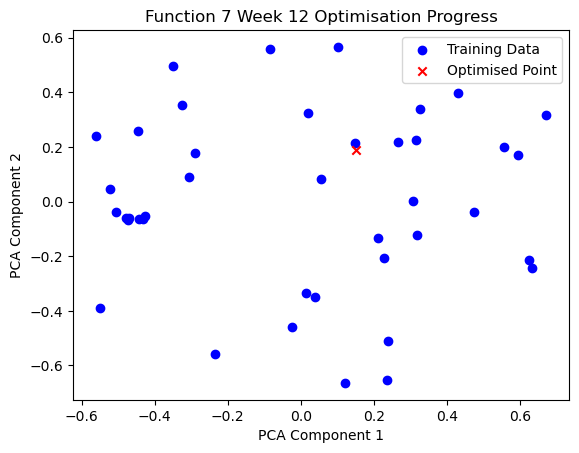

In [14]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution
from scipy.stats import norm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================================
# Step 0: Optional reproducibility
# ==========================================
# np.random.seed(42)

# ==============================
# Step 1: Updated Training Data (Weeks 1–11)
# ==============================
X_train = np.array([
    [0.27262382, 0.32449536, 0.89710881, 0.83295115, 0.15406269, 0.79586362],
    [0.54300258, 0.92469390, 0.34156746, 0.64648585, 0.71844033, 0.34313266],
    [0.09083225, 0.66152938, 0.06593091, 0.25857701, 0.96345285, 0.64026540],
    [0.11886697, 0.61505494, 0.90581639, 0.85530030, 0.41363143, 0.58523563],
    [0.63021764, 0.83809690, 0.68001305, 0.73189509, 0.52673671, 0.34842921],
    [0.76491917, 0.25588292, 0.60908422, 0.21807904, 0.32294277, 0.09579366],
    [0.05789554, 0.49167222, 0.24742222, 0.21811844, 0.42042833, 0.73096984],
    [0.19525188, 0.07922665, 0.55458046, 0.17056682, 0.01494418, 0.10703171],
    [0.64230298, 0.83687455, 0.02179269, 0.10148801, 0.68307083, 0.69241640],
    [0.78994255, 0.19554501, 0.57562333, 0.07365919, 0.25904917, 0.05109986],
    [0.52849733, 0.45742436, 0.36009569, 0.36204551, 0.81689098, 0.63747637],
    [0.72261522, 0.01181284, 0.06364591, 0.16517311, 0.07924415, 0.35995166],
    [0.07566492, 0.33450212, 0.13273274, 0.60831236, 0.91838592, 0.82233079],
    [0.94245084, 0.37743962, 0.48612233, 0.22879108, 0.08263175, 0.71195755],
    [0.14864702, 0.03394336, 0.72880565, 0.31606646, 0.02176938, 0.51691776],
    [0.81711239, 0.54816823, 0.10334758, 0.12436955, 0.72823482, 0.44967361],
    [0.41762629, 0.06409998, 0.24566877, 0.55904080, 0.19153138, 0.25464092],
    [0.72628566, 0.46489581, 0.92457051, 0.80724540, 0.63543840, 0.14341787],
    [0.31981043, 0.52009759, 0.29067775, 0.87670668, 0.49503469, 0.61908250],
    [0.87987128, 0.39796199, 0.00363456, 0.95699064, 0.26451373, 0.11486924],
    [0.54124078, 0.63140314, 0.03190205, 0.44998156, 0.79865282, 0.63370429],
    [0.22634792, 0.11502581, 0.82474966, 0.94538372, 0.90531153, 0.95101392],
    [0.68685257, 0.04101721, 0.00757301, 0.28500900, 0.69156848, 0.65554290],
    [0.17597754, 0.62441650, 0.29554198, 0.46955276, 0.09776977, 0.72814108],
    [0.88164674, 0.20445019, 0.41447436, 0.42038468, 0.26491501, 0.73066019],
    [0.06661051, 0.52804507, 0.81609520, 0.96101714, 0.08650933, 0.77778822],
    [0.93246638, 0.48881189, 0.25860774, 0.95624344, 0.19042781, 0.51985176],
    [0.84686697, 0.14242917, 0.06066859, 0.75629213, 0.55239830, 0.08130609],
    [0.80628208, 0.32412237, 0.72607601, 0.14871213, 0.71937640, 0.36288398],
    [0.47682313, 0.34094195, 0.01433523, 0.88013956, 0.99865470, 0.07966402],
    [0.432685, 0.656678, 0.117406, 0.355722, 0.832462, 0.072554],
    [0.064512, 0.628738, 0.208047, 0.151081, 0.459044, 0.215843],
    [0.169498, 0.200735, 0.398488, 0.193487, 0.308007, 0.861833],
    [0.590337, 0.894155, 0.100647, 0.426348, 0.610301, 0.132193],
    [0.100162, 0.129269, 0.340949, 0.185690, 0.342163, 0.887286],
    [0.217715, 0.271877, 0.452090, 0.138999, 0.299528, 0.900000],
    [0.168195, 0.182499, 0.377340, 0.286153, 0.305244, 0.809137],
    [0.223242, 0.878123, 0.767165, 0.289841, 0.269890, 0.886572],
    [0.154953, 0.182499, 0.377340, 0.322056, 0.264726, 0.785520],
    [0.148200, 0.162499, 0.397337, 0.266155, 0.285244, 0.829137],
    [0.144960, 0.192489, 0.367340, 0.312059, 0.254730, 0.795520]
]) 
  
y_train = np.array([
    0.6044327 , 0.56275307, 0.00750324, 0.06142430, 0.27304680,
    0.08374657, 1.36496830, 0.09264495, 0.01786960, 0.03356494,
    0.07351630, 0.20630970, 0.00882563, 0.26840032, 0.61152553,
    0.01479818, 0.27489251, 0.06676325, 0.04211835, 0.00270147,
    0.01820907, 0.00701603, 0.10050661, 0.47539552, 0.67514163,
    0.51645722, 0.00377748, 0.00313433, 0.02134252, 0.09541116,
    1.1810801774433033, 0.17209425323684932, 2.1727059353333815, 1.199969751591025, 1.8162082720691823,
    1.6884608404828576, 2.6877991580836214, 0.33302177675628947, 2.69078138886353, 2.537464069807671,
    2.584373142172859
])

# ====================================================
# Step 2: Best Point from Week 9 for Fine-Tuning
# ====================================================
best_point_week_9 = np.array([0.154953, 0.182499, 0.377340, 0.322056, 0.264726, 0.785520])
radius = 0.005  # Small radius for fine-tuning
lower = np.clip(best_point_week_9 - radius, 0, 1)
upper = np.clip(best_point_week_9 + radius, 0, 1)
bounds = list(zip(lower, upper))

# ================================
# Step 3: Define Gaussian Process and Acquisition Function
# ================================
# Kernel for Gaussian Process
kernel = C(1.0, (1e-4, 1e1)) * RBF(1.0, (1e-4, 1e1))

# Fit Gaussian Process Model
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit the GP to the training data
gp.fit(X_train, y_train)

# Expected Improvement Acquisition Function
def expected_improvement(x, model, y_best, xi=0.01):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    improvement = mu - y_best - xi
    return improvement if sigma == 0 else -improvement * (1 - norm.cdf(improvement / sigma))

# ================================
# Step 4: Differential Evolution for Fine-Tuning
# ================================
def optimize_ei_week_12(model, bounds, xi=0.0001):
    y_best = np.max(y_train)  # Best output value from Week 9
    
    result = differential_evolution(
        lambda x: expected_improvement(x, model, y_best, xi),
        bounds=bounds,
        strategy='best1bin',
        maxiter=50,   # Few iterations for fine-tuning
        popsize=10,   # Small population
        polish=True   # Final polish to ensure best result
    )
    
    # Add small random perturbation
    epsilon = 1e-5
    next_point = np.clip(
        result.x + np.random.uniform(-epsilon, epsilon, size=len(bounds)),
        lower,
        upper
    )
    
    return next_point

# Run the optimisation for Week 12
new_query_point_week_12 = optimize_ei_week_12(gp, bounds)
print("Optimised Query Point for Week 12: ")
print(new_query_point_week_12)

# ================================
# Step 5: Optional PCA Visualisation
# ================================
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

# Plot the training data and the optimised query point
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], color='blue', label="Training Data")
plt.scatter(new_query_point_week_12[0], new_query_point_week_12[1], color='red', marker='x', label="Optimised Point")
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.title('Function 7 Week 12 Optimisation Progress')
plt.show()

Optimised Query Point for Week 12:
[0.15158736, 0.187499, 0.38234, 0.327056, 0.26971959, 0.79052]

### Interpretation of the Optimised Query Point:
This point is very close to the best point from Week 9 ([0.154953, 0.182499, 0.377340, 0.322056, 0.264726, 0.785520]), indicating that the optimisation process has refined the hyperparameters slightly, within the small search radius you specified.
The parameters have shifted by small values, which suggests a fine-tuning of the model with a focus on exploiting the region of the best-performing point from Week 9.
Next Steps:
Test the Optimised Point: You can now evaluate this optimised point on your model to see if it yields an improved output value compared to Week 9.
Verify Convergence: If the output performance continues to improve or stabilise, this may indicate that you've reached a convergence stage in your hyperparameter search.
Confirm Results: Run additional tests around this point to confirm that the performance does not degrade with slight perturbations.

## Function 8

Best point so far:
[0.068217 0.083242 0.13481  0.098558 0.754161 0.469432 0.213826 0.872809]
Score: 9.9809975624094


C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(



Learned kernel:
6.77**2 * Matern(length_scale=[5.14, 7.56, 4.06, 7.53, 16, 7.25, 5.14, 100], nu=2.5)

Optimized reduced parameters: [0.         0.12754479 0.12456312 0.45930381 0.17672649]

Optimized full parameters: [0.         0.083242   0.12754479 0.12456312 0.754161   0.45930381
 0.17672649 0.872809  ]


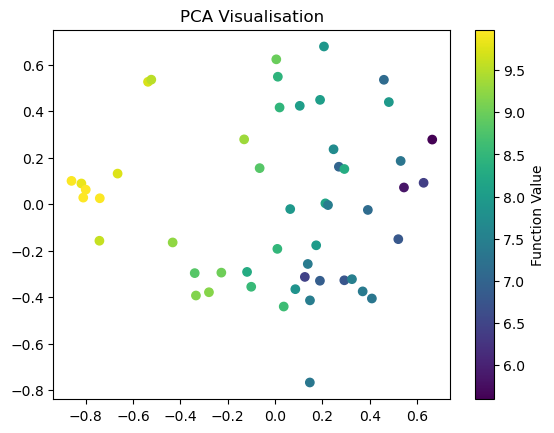

In [17]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.optimize import differential_evolution
from scipy.stats import norm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================================
# Step 0: Reproducibility (optional)
# ==========================================
# np.random.seed(42)

# ==============================
# Step 1: Updated Training Data (Weeks 1–11)
# ==============================
X_train = np.array([[0.60499445, 0.29221502, 0.90845275, 0.35550624, 0.20166872,
        0.57533801, 0.31031095, 0.73428138],
       [0.17800696, 0.56622265, 0.99486184, 0.21032501, 0.32015266,
        0.70790879, 0.63538449, 0.10713163],
       [0.00907698, 0.81162615, 0.52052036, 0.07568668, 0.26511183,
        0.09165169, 0.59241515, 0.36732026],
       [0.50602816, 0.65373012, 0.36341078, 0.17798105, 0.09372830,
        0.19742533, 0.75582690, 0.29247234],
       [0.35990926, 0.24907568, 0.49599717, 0.70921498, 0.11498719,
        0.28920692, 0.55729515, 0.59388173],
       [0.77881834, 0.00341950, 0.33798313, 0.51952778, 0.82090699,
        0.53724669, 0.55134710, 0.66003209],
       [0.90864932, 0.06224970, 0.23825955, 0.76660355, 0.13233596,
        0.99024381, 0.68806782, 0.74249594],
       [0.58637144, 0.88073573, 0.74502075, 0.54603485, 0.00964888,
        0.74899176, 0.23090707, 0.09791562],
       [0.76113733, 0.85467239, 0.38212433, 0.33735198, 0.68970832,
        0.30985305, 0.63137968, 0.04195607],
       [0.98493320, 0.69950626, 0.99888550, 0.18014846, 0.58014315,
        0.23108719, 0.49082694, 0.31368272],
       [0.11207131, 0.43773566, 0.59659878, 0.59277563, 0.22698177,
        0.41010452, 0.92123758, 0.67475276],
       [0.79188751, 0.57619134, 0.69452836, 0.28342378, 0.13675546,
        0.27916186, 0.84276726, 0.62532792],
       [0.14355030, 0.93741452, 0.23232482, 0.00904349, 0.41457893,
        0.40932517, 0.55377852, 0.20584080],
       [0.76991655, 0.45875909, 0.55900044, 0.69460444, 0.50319902,
        0.72834638, 0.78425353, 0.66313109],
       [0.05644741, 0.06595555, 0.02292868, 0.03878647, 0.40393544,
        0.80105533, 0.48830701, 0.89308498],
       [0.86243745, 0.48273382, 0.28186940, 0.54410223, 0.88749026,
        0.38265469, 0.60190199, 0.47646169],
       [0.35151190, 0.59006494, 0.90943630, 0.67840835, 0.21282566,
        0.08846038, 0.41015300, 0.19572429],
       [0.73590364, 0.03461189, 0.72803027, 0.14742652, 0.29574314,
        0.44511731, 0.97517969, 0.37433978],
       [0.68029397, 0.25510465, 0.86218799, 0.13439582, 0.32632920,
        0.28790687, 0.43501048, 0.36420013],
       [0.04432925, 0.01358149, 0.25819824, 0.57764416, 0.05127992,
        0.15856307, 0.59103012, 0.07795293],
       [0.77834548, 0.75114565, 0.31414221, 0.90298577, 0.33538166,
        0.38632267, 0.74897249, 0.98875510],
       [0.89888711, 0.52364170, 0.87678325, 0.21869645, 0.90026089,
        0.28276624, 0.91107791, 0.47239822],
       [0.14512029, 0.11932754, 0.42088822, 0.38760861, 0.15542283,
        0.87517163, 0.51055967, 0.72861058],
       [0.33895442, 0.56693202, 0.37675110, 0.09891573, 0.65945169,
        0.24554809, 0.76248278, 0.73215347],
       [0.17615002, 0.29396143, 0.97567997, 0.79393631, 0.92340076,
        0.03084229, 0.80325452, 0.59589758],
       [0.02894663, 0.02827906, 0.48137155, 0.61317460, 0.67266045,
        0.02211341, 0.60148330, 0.52488505],
       [0.19263987, 0.63067728, 0.41679584, 0.49052929, 0.79608602,
        0.65456706, 0.27624119, 0.29551759],
       [0.94318502, 0.21885062, 0.72118408, 0.42459707, 0.98690200,
        0.53518298, 0.71474318, 0.96009372],
       [0.53272140, 0.83369260, 0.07139900, 0.11681148, 0.73069311,
        0.93737559, 0.86650798, 0.12790200],
       [0.44709584, 0.84395253, 0.72954612, 0.63915138, 0.40928714,
        0.13264569, 0.03590888, 0.44683847],
       [0.38222497, 0.55713584, 0.85310163, 0.33379569, 0.26572127,
        0.48087292, 0.23764706, 0.76863196],
       [0.53281953, 0.86230848, 0.53826712, 0.04944293, 0.71970119,
        0.90670590, 0.10823094, 0.52534791],
       [0.39486519, 0.33180167, 0.74075430, 0.69786172, 0.73740444,
        0.78377681, 0.25449546, 0.87114551],
       [0.98594539, 0.87305363, 0.07039262, 0.05358729, 0.73415296,
        0.52025852, 0.81104004, 0.10336036],
       [0.96457339, 0.97397979, 0.66375335, 0.66221599, 0.67312167,
        0.90523762, 0.45887462, 0.56091750],
       [0.47207071, 0.16820264, 0.08642757, 0.45265551, 0.48061922,
        0.62243949, 0.92897446, 0.11253627],
       [0.85600695, 0.63889370, 0.32619202, 0.66850311, 0.24029837,
        0.21029889, 0.16754636, 0.96358986],
       [0.81003174, 0.63504604, 0.26954758, 0.86960534, 0.66192159,
        0.25225873, 0.76567003, 0.89054867],
       [0.79625252, 0.00703653, 0.35569738, 0.48756605, 0.74051962,
        0.70665010, 0.99291449, 0.38173437],
       [0.48124533, 0.10246072, 0.21948594, 0.67732237, 0.24750919,
        0.24434086, 0.16382453, 0.71596164],
       [0.895434, 0.912022, 0.098160, 0.036667, 0.445138, 0.679791, 0.229544, 0.761742],
       [0.533209, 0.898485, 0.699395, 0.112874, 0.946419, 0.108092, 0.263289, 0.345445],
       [0.294680, 0.171230, 0.131225, 0.039384, 0.977541, 0.183968, 0.045086, 0.037349],
       [0.182500, 0.751289, 0.096803, 0.093917, 0.932979, 0.266073, 0.082636, 0.887906],
       [0.058026, 0.129966, 0.113848, 0.912375, 0.765246, 0.849704, 0.253476, 0.072370],
       [0.127331, 0.071329, 0.181538, 0.131744, 0.911727, 0.835220, 0.073672, 0.737489],
       [0.160454, 0.195631, 0.051447, 0.061853, 0.379923, 0.160398, 0.107137, 0.711175],
       [0.135802, 0.083242, 0.215911, 0.077784, 0.754161, 0.462093, 0.217830, 0.872809],
       [0.095802, 0.083242, 0.175915, 0.037784, 0.754161, 0.474990, 0.189665, 0.872809],
       [0.035804, 0.083242, 0.162876, 0.000006, 0.754161, 0.473620, 0.157155, 0.872809],
       [0.068217, 0.083242, 0.134810, 0.098558, 0.754161, 0.469432, 0.213826, 0.872809]])  

y_train = np.array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
                    8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
                    7.85454099, 6.79198578, 8.97655402, 7.37908290, 9.59848200,
                    8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
                    7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
                    8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
                    7.92375877, 8.42175924, 8.27806240, 7.11345716, 6.40258841,
                    8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525,
                    8.0383561825836, 7.911617829373, 9.7162173430324, 9.5189864611379, 9.257621188839,
                    9.8315933694244, 9.742281901602, 9.9550567121514, 9.9672589241384, 9.9487000479814,
                    9.9809975624094])

# ==========================================
# Step 2: Best point so far
# ==========================================
best_idx = np.argmax(y_train)
best_point = X_train[best_idx]
best_score = y_train[best_idx]

print("Best point so far:")
print(best_point)
print("Score:", best_score)

# ==========================================
# Step 3: Gaussian Process (ARD Matern)
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[1]*8,
    length_scale_bounds=(1e-2, 1e2),
    nu=2.5
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-3,
    normalize_y=True,
    n_restarts_optimizer=12
)

gp.fit(X_train, y_train)

print("\nLearned kernel:")
print(gp.kernel_)

# ==========================================
# Step 4: Expected Improvement (EI)
# ==========================================
def expected_improvement(x_reduced, model, y_best, xi=0.001):
    x_full = best_point.copy()

    # Insert reduced variables into full vector
    x_full[important_dims] = x_reduced
    x_full = x_full.reshape(1, -1)

    mu, sigma = model.predict(x_full, return_std=True)
    sigma = np.maximum(sigma, 1e-6)

    imp = mu - y_best + xi
    Z = imp / sigma

    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei

# ==========================================
# Step 5: Optimisation using Differential Evolution
# ==========================================
# Differential Evolution for 8 dimensions
important_dims = [0, 2, 3, 5, 6]
bounds = [(0, 1)] * len(important_dims)

result = differential_evolution(
    expected_improvement, bounds, args=(gp, best_score, 0.001),
    maxiter=100, popsize=50, recombination=0.7, mutation=(0.5, 1),
    seed=42
)

best_reduced_point = result.x
print("\nOptimized reduced parameters:", best_reduced_point)

# Translate reduced parameters back into the full parameter space
best_full_point = best_point.copy()
best_full_point[important_dims] = best_reduced_point

print("\nOptimized full parameters:", best_full_point)

# ==========================================
# Step 6: Confirm Best Solution (optional)
# ==========================================
# Visualize the process via PCA or 2D plots if needed
pca = PCA(n_components=2)
X_train_reduced = pca.fit_transform(X_train)
plt.scatter(X_train_reduced[:, 0], X_train_reduced[:, 1], c=y_train, cmap='viridis')
plt.colorbar(label='Function Value')
plt.title("PCA Visualisation")
plt.show()

### Summary of Results:
Best Point So Far (Initial Optimal Point):
Coordinates: [0.068217, 0.083242, 0.13481, 0.098558, 0.754161, 0.469432, 0.213826, 0.872809]
Score: 9.9809975624094
This is the current "best" solution from previous evaluations, which will now guide the search for further improvements.
Learned Kernel:
The Gaussian Process has learned a Matern kernel with specific length scales for each dimension:
6.77**2 * Matern(length_scale=[5.14, 7.56, 4.06, 7.53, 16, 7.25, 5.14, 100], nu=2.5)

These length scales describe how smooth the function is expected to behave in each of the 8 dimensions.

Optimised Reduced Parameters:
The new reduced parameters (i.e., optimized for the dimensions that matter most):
Reduced Parameters: [0.0, 0.12754479, 0.12456312, 0.45930381, 0.17672649]

Optimised Full Parameters (Function 8 Week 12 Query Point):
These are the optimised parameters for the full 8-dimensional input space, after mapping the reduced parameters back to the full space:
Query Point: [0.0, 0.083242, 0.12754479, 0.12456312, 0.754161, 0.45930381, 0.17672649, 0.872809]

### Interpretation:
You’ve found a new query point at [0.0, 0.083242, 0.12754479, 0.12456312, 0.754161, 0.45930381, 0.17672649, 0.872809], which is a refinement of the previous best point.
This new query point is expected to improve the score further during the convergence phase of the optimisation, given that it maximises the Expected Improvement (EI).

### Next Steps:
Evaluate the Function: Run the function at the new query point and see if the performance (score) improves.
Continue the Confirmation Process: If the score improves, you can confirm the new best point. If there is no significant improvement, you may continue iterating or stop once you've confirmed convergence